In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import Margins

raw = sm.datasets.anes96.load_pandas().data.copy()
# 7-point PID coded 0..6. Keep covariates compact for the demo.
df = raw[["PID", "TVnews", "selfLR", "age", "educ", "income"]].dropna().copy()
df["PID"] = df["PID"].astype(int)
print(df.describe().round(2))
print("\nOutcome distribution:")
print(df["PID"].value_counts().sort_index())

          PID  TVnews  selfLR     age    educ  income
count  944.00  944.00  944.00  944.00  944.00  944.00
mean     2.84    3.73    4.33   47.04    4.57   16.33
std      2.27    2.68    1.44   16.42    1.60    5.97
min      0.00    0.00    1.00   19.00    1.00    1.00
25%      1.00    1.00    3.00   34.00    3.00   14.00
50%      2.00    3.00    4.00   44.00    4.00   17.00
75%      5.00    7.00    6.00   58.00    6.00   21.00
max      6.00    7.00    7.00   91.00    7.00   24.00

Outcome distribution:
PID
0    200
1    180
2    108
3     37
4     94
5    150
6    175
Name: count, dtype: int64


In [2]:
fit = smf.mnlogit(
    "PID ~ TVnews + selfLR + age + educ + income",
    data=df,
).fit(disp=False)
print(fit.summary().tables[1])

     PID=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2758      0.620     -0.445      0.656      -1.491       0.939
TVnews        -0.0994      0.043     -2.290      0.022      -0.185      -0.014
selfLR         0.2900      0.094      3.076      0.002       0.105       0.475
age           -0.0186      0.007     -2.619      0.009      -0.033      -0.005
educ           0.0808      0.073      1.100      0.271      -0.063       0.225
income         0.0041      0.018      0.233      0.815      -0.030       0.039
------------------------------------------------------------------------------
     PID=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.4823      0.750     -3.311      0.001      -3.952      -1.013
TVnews        -0.0368      0.050     -0.731      0.4

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:875: UserWarning: Delta-method curvature κ=0.533 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


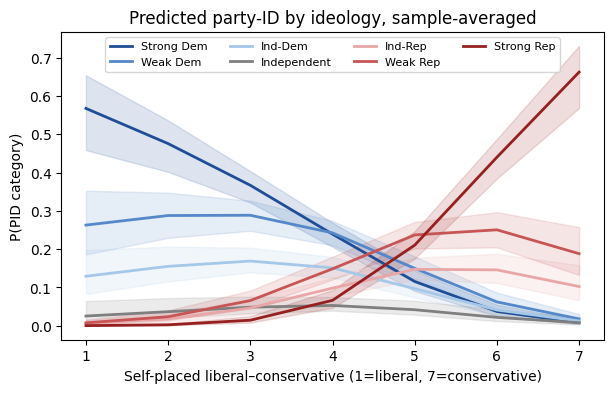

In [3]:
import matplotlib.pyplot as plt

m = Margins.linear_scale(fit, at="overall")
lr_grid = list(range(1, 8))  # selfLR scale 1..7
res = m.predict(atexog={"selfLR": lr_grid})

est = np.asarray(res.estimate)        # (n_lr, n_outcomes)
ci = np.asarray(res.conf_int())       # (2, n_lr, n_outcomes)
n_lr, n_out = est.shape

pid_labels = [
    "Strong Dem", "Weak Dem", "Ind-Dem",
    "Independent",
    "Ind-Rep", "Weak Rep", "Strong Rep",
]
# Blue = Democrat, red = Republican, grey = independent — standard US
# political color convention.
colors = ["#1f4e96", "#5588c8", "#a6c8e8",
          "#7f7f7f",
          "#e8a6a6", "#c85555", "#961f1f"]

fig, ax = plt.subplots(figsize=(7, 4))
for j in range(n_out):
    ax.plot(lr_grid, est[:, j], color=colors[j], label=pid_labels[j], lw=2)
    ax.fill_between(
        lr_grid, ci[0, :, j], ci[1, :, j], alpha=0.15, color=colors[j]
    )
ax.set(xlabel="Self-placed liberal–conservative (1=liberal, 7=conservative)",
       ylabel="P(PID category)",
       title="Predicted party-ID by ideology, sample-averaged")
ax.legend(loc="upper center", ncol=4, fontsize=8)

In [4]:
ame_lr = m.dydx("selfLR")
print(ame_lr.summary())

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:972: UserWarning: Delta-method curvature κ=0.729 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


             Margins Result (simulation, level=0.95)             
            estimate  std err  statistic  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------------
selfLR (0)   -0.0967   0.0078    -0.0967  0.000  -0.1119, -0.0805
selfLR (1)   -0.0513   0.0072    -0.0513  0.000  -0.0663, -0.0378
selfLR (2)   -0.0274   0.0056    -0.0274  0.000  -0.0388, -0.0167
selfLR (3)   -0.0052   0.0034    -0.0052  0.052   -0.0132, 0.0000
selfLR (4)    0.0198   0.0054     0.0198  0.000    0.0099, 0.0307
selfLR (5)    0.0363   0.0068     0.0363  0.000    0.0237, 0.0503
selfLR (6)    0.1243   0.0084     0.1243  0.000    0.1082, 0.1411

n = 944
WARNING — Fallback triggered: kappa=0.729>threshold=0.3
κ: max=0.729


In [5]:
print(m.dydx("educ").summary())

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:972: UserWarning: Delta-method curvature κ=0.407 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


            Margins Result (simulation, level=0.95)            
          estimate  std err  statistic  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------
educ (0)   -0.0197   0.0084    -0.0197  0.021  -0.0361, -0.0031
educ (1)   -0.0054   0.0084    -0.0054  0.509   -0.0220, 0.0113
educ (2)    0.0065   0.0070     0.0065  0.353   -0.0072, 0.0205
educ (3)   -0.0056   0.0048    -0.0056  0.193   -0.0158, 0.0031
educ (4)    0.0016   0.0067     0.0016  0.807   -0.0114, 0.0148
educ (5)    0.0051   0.0079     0.0051  0.546   -0.0108, 0.0203
educ (6)    0.0174   0.0075     0.0174  0.014    0.0031, 0.0322

n = 944
WARNING — Fallback triggered: kappa=0.407>threshold=0.3
κ: max=0.407


In [6]:
import jax.numpy as jnp

def dem_minus_rep(p):
    # p: (n_scenarios, n_outcomes=7) — per-scenario category probabilities.
    # Returns one gap per scenario.
    dem = p[..., 0:3].sum(axis=-1)   # strong Dem, weak Dem, ind-Dem
    rep = p[..., 4:7].sum(axis=-1)   # ind-Rep, weak Rep, strong Rep
    return dem - rep

# One scenario per ideology level; compose collapses the outcome axis.
scenarios = [{"atexog": {"selfLR": v}, "label": f"selfLR={v}"}
             for v in lr_grid]
res_diff = m.evaluate(scenarios=scenarios, compose=dem_minus_rep)
print(res_diff.summary())

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:1345: UserWarning: Delta-method curvature κ=0.336 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


              Margins Result (simulation, level=0.95)              
              estimate  std err  statistic  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------
selfLR=1 (0)    0.9461   0.0173     0.9461  0.000    0.9004, 0.9669
selfLR=1 (1)    0.8752   0.0236     0.8752  0.000    0.8152, 0.9088
selfLR=1 (2)    0.6979   0.0331     0.6979  0.000    0.6206, 0.7513
selfLR=1 (3)    0.3196   0.0379     0.3196  0.000    0.2387, 0.3868
selfLR=1 (4)   -0.2329   0.0414    -0.2329  0.000  -0.3118, -0.1496
selfLR=1 (5)   -0.6961   0.0367    -0.6961  0.000  -0.7566, -0.6138
selfLR=1 (6)   -0.9153   0.0196    -0.9153  0.000  -0.9427, -0.8680

n = 944
WARNING — Fallback triggered: kappa=0.336>threshold=0.3
κ: max=0.336
